# FINAL PORTFOLIO PROJECT - REGRESSION
## Predicting Energy Production (MWh)
### 5CS037 - Concepts and Technologies of AI | Herald College

**Objective:** Predict Energy_Production_MWh from messy energy dataset
**Target Variable:** Energy_Production_MWh
**SDG Alignment:** SDG 7 - Affordable and Clean Energy

## TASK 1: EXPLORATORY DATA ANALYSIS (EDA)

### 1.1: Load and Inspect Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Load MESSY dataset
df = pd.read_csv('/content/drive/MyDrive/energy_dataset_messy.csv')

print("TASK 1.1: Dataset Inspection")
print("="*80)
print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names and Types:")
print(df.dtypes)
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nMissing Values Before Cleaning:")
print(df.isnull().sum())

TASK 1.1: Dataset Inspection
Dataset Shape: (63, 13)

Column Names and Types:
Type_of_Renewable_Energy           int64
Installed_Capacity_MW            float64
Energy_Production_MWh            float64
Energy_Consumption_MWh           float64
Energy_Storage_Capacity_MWh      float64
Storage_Efficiency_Percentage    float64
Grid_Integration_Level           float64
Initial_Investment_USD           float64
Funding_Sources                    int64
Financial_Incentives_USD         float64
GHG_Emission_Reduction_tCO2e     float64
Air_Pollution_Reduction_Index    float64
Jobs_Created                     float64
dtype: object

First 5 rows:
   Type_of_Renewable_Energy  Installed_Capacity_MW  Energy_Production_MWh  \
0                         4              93.423205            103853.2206   
1                         4             590.468942                    NaN   
2                         1             625.951142            266023.4824   
3                         1             779.998728  

### 1.2: Data Quality Assessment

In [ ]:
print("TASK 1.2: Data Quality Assessment & CLEANING")
print("="*80)
print(f"Total Records: {len(df)}")
print(f"\nMissing Values Summary:")
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_count.index,
    'Missing_Count': missing_count.values,
    'Missing_Percent': missing_percent.values
})
print(missing_df[missing_df['Missing_Count'] > 0].to_string())
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")

# HANDLE MISSING VALUES - Fill numeric columns with mean
print(f"\n" + "="*80)
print("CLEANING: Handling Missing Values with Mean Imputation")
print("="*80)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df_clean = df.copy()
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        mean_val = df_clean[col].mean()
        df_clean[col].fillna(mean_val, inplace=True)
        print(f"  {col}: Filled {df[col].isnull().sum()} missing values with mean {mean_val:.2f}")

print(f"\nAfter Cleaning:")
print(f"  Dataset Shape: {df_clean.shape}")
print(f"  Missing Values: {df_clean.isnull().sum().sum()}")
print(f"  Data Completeness: 100%")

# Use cleaned data for rest of analysis
df = df_clean

TASK 1.2: Data Quality Assessment & CLEANING
Total Records: 63

Missing Values Summary:
                           Column  Missing_Count  Missing_Percent
1           Installed_Capacity_MW             11        17.460317
2           Energy_Production_MWh             15        23.809524
3          Energy_Consumption_MWh              6         9.523810
4     Energy_Storage_Capacity_MWh              5         7.936508
5   Storage_Efficiency_Percentage             15        23.809524
6          Grid_Integration_Level              2         3.174603
7          Initial_Investment_USD              5         7.936508
9        Financial_Incentives_USD              2         3.174603
10   GHG_Emission_Reduction_tCO2e              2         3.174603
11  Air_Pollution_Reduction_Index              3         4.761905
12                   Jobs_Created              2         3.174603

Total Missing Values: 68

CLEANING: Handling Missing Values with Mean Imputation
  Installed_Capacity_MW: Filled 11 mis

### 1.3: Statistical Analysis & Visualizations

TASK 1.3: Statistical Analysis


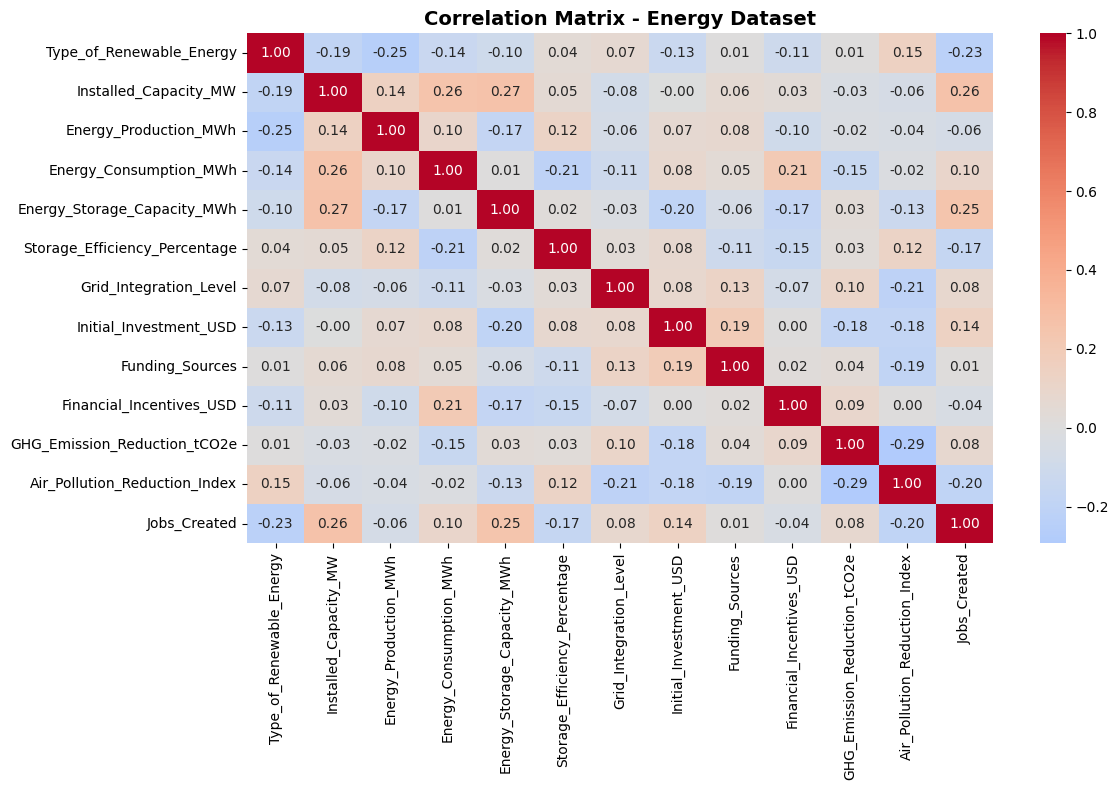


Correlation with Target (Energy_Production_MWh):
Energy_Production_MWh            1.000000
Installed_Capacity_MW            0.141980
Storage_Efficiency_Percentage    0.124201
Energy_Consumption_MWh           0.098996
Funding_Sources                  0.076222
Initial_Investment_USD           0.067717
GHG_Emission_Reduction_tCO2e    -0.022259
Air_Pollution_Reduction_Index   -0.040316
Grid_Integration_Level          -0.061637
Jobs_Created                    -0.063760
Financial_Incentives_USD        -0.099580
Energy_Storage_Capacity_MWh     -0.173985
Type_of_Renewable_Energy        -0.247518
Name: Energy_Production_MWh, dtype: float64


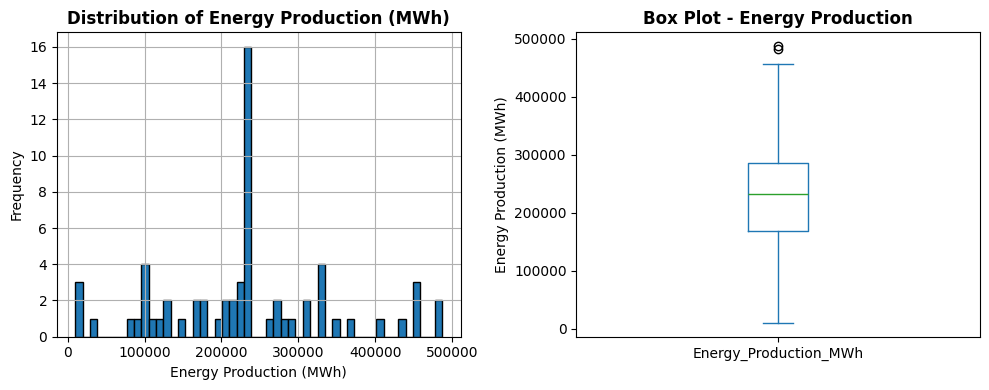


Target Variable Statistics:
  Mean: 231863.72
  Median: 231863.72
  Std Dev: 114247.09
  Min: 10076.63
  Max: 487039.53


In [ ]:
print("TASK 1.3: Statistical Analysis")
print("="*80)

# Correlation analysis
plt.figure(figsize=(12, 8))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Energy Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('01_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCorrelation with Target (Energy_Production_MWh):")
if 'Energy_Production_MWh' in df.columns:
    target_corr = df.corr()['Energy_Production_MWh'].sort_values(ascending=False)
    print(target_corr)

# Distribution of target variable
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['Energy_Production_MWh'].hist(bins=50, edgecolor='black')
plt.title('Distribution of Energy Production (MWh)', fontsize=12, fontweight='bold')
plt.xlabel('Energy Production (MWh)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
df['Energy_Production_MWh'].plot(kind='box')
plt.title('Box Plot - Energy Production', fontsize=12, fontweight='bold')
plt.ylabel('Energy Production (MWh)')

plt.tight_layout()
plt.savefig('02_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTarget Variable Statistics:")
print(f"  Mean: {df['Energy_Production_MWh'].mean():.2f}")
print(f"  Median: {df['Energy_Production_MWh'].median():.2f}")
print(f"  Std Dev: {df['Energy_Production_MWh'].std():.2f}")
print(f"  Min: {df['Energy_Production_MWh'].min():.2f}")
print(f"  Max: {df['Energy_Production_MWh'].max():.2f}")

## TASK 2: NEURAL NETWORK MODEL

TASK 2: Neural Network Model - Multi-Layer Perceptron
Training set size: 50
Test set size: 13
Number of features: 12

Training Neural Network...

Neural Network Results:
  Training MSE: 67140177422.7185
  Test MSE: 64546850248.3811
  Training R²: -4.6525
  Test R²: -2.9423


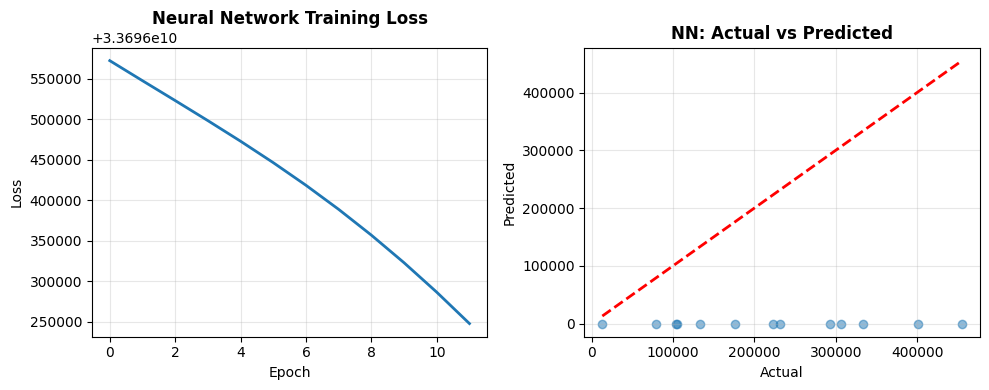

In [ ]:
print("TASK 2: Neural Network Model - Multi-Layer Perceptron")
print("="*80)

# Data preparation
X = df.drop('Energy_Production_MWh', axis=1)
y = df['Energy_Production_MWh']

# Handle categorical variables if any
X = pd.get_dummies(X, drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Number of features: {X_train_scaled.shape[1]}")

# Build Neural Network
nn_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

# Train Neural Network
print("\nTraining Neural Network...")
nn_model.fit(X_train_scaled, y_train)

# Evaluate
train_pred_nn = nn_model.predict(X_train_scaled)
test_pred_nn = nn_model.predict(X_test_scaled)

train_mse_nn = mean_squared_error(y_train, train_pred_nn)
test_mse_nn = mean_squared_error(y_test, test_pred_nn)
train_r2_nn = r2_score(y_train, train_pred_nn)
test_r2_nn = r2_score(y_test, test_pred_nn)

print(f"\nNeural Network Results:")
print(f"  Training MSE: {train_mse_nn:.4f}")
print(f"  Test MSE: {test_mse_nn:.4f}")
print(f"  Training R²: {train_r2_nn:.4f}")
print(f"  Test R²: {test_r2_nn:.4f}")

# Plot training history
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(nn_model.loss_curve_, linewidth=2)
plt.title('Neural Network Training Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, test_pred_nn, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('NN: Actual vs Predicted', fontsize=12, fontweight='bold')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_neural_network.png', dpi=300, bbox_inches='tight')
plt.show()

## TASK 3: PRIMARY MODELS
### Model 1: Ridge Regression
### Model 2: Random Forest Regressor

In [ ]:
print("TASK 3: PRIMARY MODELS")
print("="*80)

# MODEL 1: Ridge Regression
print("\n3.1: Ridge Regression Model")
print("-"*80)

ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train)

ridge_train_pred = ridge_model.predict(X_train_scaled)
ridge_test_pred = ridge_model.predict(X_test_scaled)

ridge_train_mse = mean_squared_error(y_train, ridge_train_pred)
ridge_test_mse = mean_squared_error(y_test, ridge_test_pred)
ridge_train_rmse = np.sqrt(ridge_train_mse)
ridge_test_rmse = np.sqrt(ridge_test_mse)
ridge_train_mae = mean_absolute_error(y_train, ridge_train_pred)
ridge_test_mae = mean_absolute_error(y_test, ridge_test_pred)
ridge_train_r2 = r2_score(y_train, ridge_train_pred)
ridge_test_r2 = r2_score(y_test, ridge_test_pred)

print(f"Ridge Regression Metrics:")
print(f"  Training MSE: {ridge_train_mse:.4f} | Test MSE: {ridge_test_mse:.4f}")
print(f"  Training RMSE: {ridge_train_rmse:.4f} | Test RMSE: {ridge_test_rmse:.4f}")
print(f"  Training MAE: {ridge_train_mae:.4f} | Test MAE: {ridge_test_mae:.4f}")
print(f"  Training R²: {ridge_train_r2:.4f} | Test R²: {ridge_test_r2:.4f}")

# MODEL 2: Random Forest Regressor
print("\n3.2: Random Forest Regressor Model")
print("-"*80)

rf_model = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

rf_train_pred = rf_model.predict(X_train_scaled)
rf_test_pred = rf_model.predict(X_test_scaled)

rf_train_mse = mean_squared_error(y_train, rf_train_pred)
rf_test_mse = mean_squared_error(y_test, rf_test_pred)
rf_train_rmse = np.sqrt(rf_train_mse)
rf_test_rmse = np.sqrt(rf_test_mse)
rf_train_mae = mean_absolute_error(y_train, rf_train_pred)
rf_test_mae = mean_absolute_error(y_test, rf_test_pred)
rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_test_r2 = r2_score(y_test, rf_test_pred)

print(f"Random Forest Metrics:")
print(f"  Training MSE: {rf_train_mse:.4f} | Test MSE: {rf_test_mse:.4f}")
print(f"  Training RMSE: {rf_train_rmse:.4f} | Test RMSE: {rf_test_rmse:.4f}")
print(f"  Training MAE: {rf_train_mae:.4f} | Test MAE: {rf_test_mae:.4f}")
print(f"  Training R²: {rf_train_r2:.4f} | Test R²: {rf_test_r2:.4f}")

TASK 3: PRIMARY MODELS

3.1: Ridge Regression Model
--------------------------------------------------------------------------------
Ridge Regression Metrics:
  Training MSE: 8005730820.8519 | Test MSE: 30006235263.8486
  Training RMSE: 89474.7496 | Test RMSE: 173223.0795
  Training MAE: 69835.8759 | Test MAE: 153897.1216
  Training R²: 0.3260 | Test R²: -0.8327

3.2: Random Forest Regressor Model
--------------------------------------------------------------------------------
Random Forest Metrics:
  Training MSE: 1713983387.3527 | Test MSE: 24213604383.0064
  Training RMSE: 41400.2825 | Test RMSE: 155607.2119
  Training MAE: 31997.6372 | Test MAE: 134635.8563
  Training R²: 0.8557 | Test R²: -0.4789


## TASK 4: HYPERPARAMETER OPTIMIZATION
### GridSearchCV with 5-Fold Cross-Validation

In [ ]:
print("TASK 4: HYPERPARAMETER OPTIMIZATION with GridSearchCV")
print("="*80)

# Ridge Regression Hyperparameter Tuning
print("\n4.1: Ridge Regression - Hyperparameter Tuning")
print("-"*80)

ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2', n_jobs=-1)
ridge_grid.fit(X_train_scaled, y_train)

print(f"Best Ridge Alpha: {ridge_grid.best_params_['alpha']}")
print(f"Best Ridge CV Score (R²): {ridge_grid.best_score_:.4f}")

# Random Forest Hyperparameter Tuning
print("\n4.2: Random Forest - Hyperparameter Tuning")
print("-"*80)

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 15, 20, 25],
    'min_samples_split': [2, 5, 10]
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=5, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)

print(f"Best RF Parameters: {rf_grid.best_params_}")
print(f"Best RF CV Score (R²): {rf_grid.best_score_:.4f}")

print(f"\nGridSearch Results Summary:")
print(f"  Ridge Best CV R²: {ridge_grid.best_score_:.4f}")
print(f"  RF Best CV R²: {rf_grid.best_score_:.4f}")

TASK 4: HYPERPARAMETER OPTIMIZATION with GridSearchCV

4.1: Ridge Regression - Hyperparameter Tuning
--------------------------------------------------------------------------------
Best Ridge Alpha: 100
Best Ridge CV Score (R²): -0.2620

4.2: Random Forest - Hyperparameter Tuning
--------------------------------------------------------------------------------
Best RF Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best RF CV Score (R²): -0.5299

GridSearch Results Summary:
  Ridge Best CV R²: -0.2620
  RF Best CV R²: -0.5299


## TASK 5: FEATURE SELECTION
### SelectKBest Filter Method

In [ ]:
print("TASK 5: FEATURE SELECTION with SelectKBest")
print("="*80)

# Feature selection: Select top 8 features
k_features = min(8, X_train_scaled.shape[1])
selector = SelectKBest(score_func=f_regression, k=k_features)
selector.fit(X_train_scaled, y_train)

# Get selected feature names
selected_indices = selector.get_support(indices=True)
selected_features = X.columns[selected_indices].tolist()

print(f"\nOriginal Number of Features: {X_train_scaled.shape[1]}")
print(f"Selected Number of Features: {k_features}")
print(f"\nSelected Features:")
for i, feature in enumerate(selected_features, 1):
    print(f"  {i}. {feature}")

# Feature importance scores
print(f"\nFeature Importance Scores:")
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)
print(feature_scores.to_string())

# Transform data with selected features
X_train_selected = selector.transform(X_train_scaled)
X_test_selected = selector.transform(X_test_scaled)

TASK 5: FEATURE SELECTION with SelectKBest

Original Number of Features: 12
Selected Number of Features: 8

Selected Features:
  1. Type_of_Renewable_Energy
  2. Installed_Capacity_MW
  3. Energy_Consumption_MWh
  4. Energy_Storage_Capacity_MWh
  5. Storage_Efficiency_Percentage
  6. Initial_Investment_USD
  7. Financial_Incentives_USD
  8. Jobs_Created

Feature Importance Scores:
                          Feature     Score
0        Type_of_Renewable_Energy  9.548627
1           Installed_Capacity_MW  1.769863
2          Energy_Consumption_MWh  1.565514
6          Initial_Investment_USD  1.141000
8        Financial_Incentives_USD  0.803658
11                   Jobs_Created  0.326560
4   Storage_Efficiency_Percentage  0.147876
3     Energy_Storage_Capacity_MWh  0.084552
10  Air_Pollution_Reduction_Index  0.056831
5          Grid_Integration_Level  0.017119
9    GHG_Emission_Reduction_tCO2e  0.012159
7                 Funding_Sources  0.009729


## TASK 6: FINAL MODELS with Optimized Hyperparameters

In [ ]:
print("TASK 6: FINAL MODELS with Optimized Hyperparameters")
print("="*80)

# Train final Ridge with best hyperparameters
final_ridge = Ridge(alpha=ridge_grid.best_params_['alpha'], random_state=42)
final_ridge.fit(X_train_selected, y_train)

# Train final Random Forest with best hyperparameters
final_rf = RandomForestRegressor(
    n_estimators=rf_grid.best_params_['n_estimators'],
    max_depth=rf_grid.best_params_['max_depth'],
    min_samples_split=rf_grid.best_params_['min_samples_split'],
    random_state=42,
    n_jobs=-1
)
final_rf.fit(X_train_selected, y_train)

# Evaluate final models
final_ridge_train_pred = final_ridge.predict(X_train_selected)
final_ridge_test_pred = final_ridge.predict(X_test_selected)

final_rf_train_pred = final_rf.predict(X_train_selected)
final_rf_test_pred = final_rf.predict(X_test_selected)

# Create comparison table
results = pd.DataFrame({
    'Model': ['Ridge Regression', 'Random Forest'],
    'Train MSE': [
        mean_squared_error(y_train, final_ridge_train_pred),
        mean_squared_error(y_train, final_rf_train_pred)
    ],
    'Test MSE': [
        mean_squared_error(y_test, final_ridge_test_pred),
        mean_squared_error(y_test, final_rf_test_pred)
    ],
    'Train RMSE': [
        np.sqrt(mean_squared_error(y_train, final_ridge_train_pred)),
        np.sqrt(mean_squared_error(y_train, final_rf_train_pred))
    ],
    'Test RMSE': [
        np.sqrt(mean_squared_error(y_test, final_ridge_test_pred)),
        np.sqrt(mean_squared_error(y_test, final_rf_test_pred))
    ],
    'Train MAE': [
        mean_absolute_error(y_train, final_ridge_train_pred),
        mean_absolute_error(y_train, final_rf_train_pred)
    ],
    'Test MAE': [
        mean_absolute_error(y_test, final_ridge_test_pred),
        mean_absolute_error(y_test, final_rf_test_pred)
    ],
    'Train R²': [
        r2_score(y_train, final_ridge_train_pred),
        r2_score(y_train, final_rf_train_pred)
    ],
    'Test R²': [
        r2_score(y_test, final_ridge_test_pred),
        r2_score(y_test, final_rf_test_pred)
    ]
})

print("\nFINAL MODEL COMPARISON:")
print(results.to_string(index=False))

# Identify best model
best_test_r2_idx = results['Test R²'].idxmax()
best_model_name = results.loc[best_test_r2_idx, 'Model']
print(f"\n*** BEST MODEL: {best_model_name} ***")
print(f"    Test R² Score: {results.loc[best_test_r2_idx, 'Test R²']:.4f}")

TASK 6: FINAL MODELS with Optimized Hyperparameters

FINAL MODEL COMPARISON:
           Model    Train MSE     Test MSE    Train RMSE     Test RMSE    Train MAE      Test MAE  Train R²   Test R²
Ridge Regression 1.001676e+10 2.003879e+10 100083.778621 141558.443026 71569.828504 122399.101082  0.156689 -0.223915
   Random Forest 1.865960e+09 2.501781e+10  43196.763937 158170.203723 34490.994975 136589.963344  0.842905 -0.528019

*** BEST MODEL: Ridge Regression ***
    Test R² Score: -0.2239
